# Nhóm 2, Notebook_C (Sinh viên A, giai đoạn 2): đặc trưng nào thật sự mang thông tin

**Đề tài**: Khoảng dự báo có cam kết bao phủ cho dung lượng pin xe điện, khi đổi xe và khi đổi thời kỳ

**Vai trò**: Notebook A dựng ra 167 đặc trưng. Notebook này trả lời câu hỏi mà một phản biện
chắc chắn sẽ hỏi: *"các bạn ném vào 167 cột, vậy cột nào có tác dụng, và có cần tới 167 không?"*.
Đây là hướng R0 trong Bảng 5 của tài liệu nhiệm vụ.

**Đầu vào**: `ev_data/data/sessions.csv`, `feature_names.csv`, `feature_names_paper.csv`, `manifest.json`
**Đầu ra**: `results/` và `fig/`, quan trọng nhất là `results/dac_trung_chon.csv`, bộ đặc trưng
rút gọn mà Notebook D sẽ dùng.
**Thời gian chạy đo được**: khoảng 20 phút trên 2 lõi CPU. Đặt `NHANH = True` để thử với 2 lượt trước.

## Câu hỏi của notebook này

| Câu hỏi | Bước trả lời | Kết quả đem vào bài báo |
|---|---|---|
| Chín nhóm đặc trưng là gì, mỗi nhóm bao nhiêu cột | Bước 0 | một bảng mô tả bộ dữ liệu |
| Từng cột một, cột nào tương quan với dung lượng | Bước 1 | hình xếp hạng đơn biến |
| Bao nhiêu cột thật ra là bản sao của nhau | Bước 2 | con số dư thừa, lý do không tin xếp hạng đơn biến |
| Mô hình dựa vào cột nào | Bước 3 | tầm quan trọng theo XGBoost |
| Xếp hạng đó có còn đúng trên **xe chưa từng thấy** không | Bước 4 | tầm quan trọng hoán vị, trung thực hơn Bước 3 |
| Bỏ hẳn một nhóm thì mất bao nhiêu | Bước 5 | bảng bỏ nhóm, hai giao thức |
| Cần bao nhiêu đặc trưng là đủ | Bước 6 | đường cong top-k, chỗ bão hoà |
| Chọn đặc trưng có ổn định giữa các xe không | Bước 7 | chỉ số Jaccard |
| Danh sách cấm có thật sự cần không | Bước 8 | thí nghiệm cố tình rò rỉ nhãn |

## Một điều phải nhớ suốt notebook

Ba cột `n_rows`, `ah`, `bms_cap` **không bao giờ** được làm đặc trưng. `ah` là tử số của nhãn,
`n_rows` là thời lượng trá hình, `bms_cap` là ước lượng của chính BMS và được giữ làm mốc so sánh
riêng. Bước 8 chứng minh bằng thí nghiệm vì sao danh sách cấm này là bắt buộc chứ không phải
cẩn thận thừa.

## Vừa làm vừa hỏi AI và ghi Audit Log

Giống Notebook A và B. Notebook này có một cái bẫy riêng mà AI hay trả lời sai:

> Nếu bạn hỏi AI *"chọn đặc trưng quan trọng nhất giúp tôi"*, phần lớn câu trả lời sẽ dùng
> `model.feature_importances_` của XGBoost rồi lấy top-k. **Chưa đủ.** Chỉ số đó đo mô hình
> *đã dựa vào* cột nào trên chính dữ liệu huấn luyện, không đo cột đó có còn hữu ích trên
> **xe khác** hay không. Với dữ liệu có cấu trúc theo xe, hai xếp hạng này lệch nhau, và cái
> quyết định kết quả bài báo là cái thứ hai. Bước 3 và Bước 4 làm cả hai rồi so.

| Ngày, bước | Prompt (rút gọn) | AI trả lời gì | Tôi kiểm tra hoặc sửa gì | Dùng vào đâu |
|---|---|---|---|---|
| 27/09, Bước 4 | chọn đặc trưng quan trọng nhất | dùng feature_importances_ lấy top 30 | thêm tầm quan trọng hoán vị đo trên xe giữ lại, hai xếp hạng lệch nhau | Bước 3 và Bước 4 |

## Bước 0: nạp dữ liệu và chia 167 đặc trưng thành chín nhóm

Kiểm mã băm trước. Nếu không khớp `manifest.json` thì bạn đang cầm bản cũ của Sinh viên A.

Chín nhóm không phải chia cho đẹp. Mỗi nhóm là một **cơ chế vật lý** khác nhau, nên khi Bước 5
bỏ đi một nhóm, ta biết mình vừa bỏ đi cái gì, chứ không phải bỏ ngẫu nhiên vài cột.

In [2]:
import json, pathlib, hashlib, warnings, time
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': .25})
TEAL, RUST, SAND, SLATE = '#0F3D3E', '#B5533C', '#C9A227', '#4B6A8A'

SEED = 42
NHANH = False                    # True: chỉ 2 lượt giữ xe, để thử nhanh
np.random.seed(SEED)

DATA = pathlib.Path('ev_data/data')
RES = pathlib.Path('results'); RES.mkdir(exist_ok=True)
FIG = pathlib.Path('fig'); FIG.mkdir(exist_ok=True)

d = pd.read_csv(DATA / 'sessions.csv', parse_dates=['t_start'])
man = json.loads((DATA / 'manifest.json').read_text())
h = hashlib.sha256((DATA / 'sessions.csv').read_bytes()).hexdigest()[:16]
print('mã băm khớp manifest:', h == man['sha256_16'])

META = ['vehicle', 'session', 't_start', 'n_rows', 'ah', 'capacity', 'bms_cap']
CAM = ['n_rows', 'ah', 'bms_cap']          # danh sách cấm, không bao giờ làm đặc trưng
FEATS = [c for c in d.columns if c not in META]
FEATS_PAPER = pd.read_csv(DATA / 'feature_names_paper.csv', header=None)[0].tolist()
assert set(FEATS_PAPER) <= set(FEATS), 'bộ 43 không nằm trong bộ mở rộng'
assert not (set(CAM) & set(FEATS)), 'một cột trong danh sách cấm đã lọt vào đặc trưng'

d = d.dropna(subset=['capacity']).reset_index(drop=True)
y = d.capacity.values
XE = [int(v) for v in d.vehicle.unique()]
print(f'{len(d):,} phiên, {len(XE)} xe, {len(FEATS)} đặc trưng, bộ bài báo {len(FEATS_PAPER)}')

mã băm khớp manifest: True
31,253 phiên, 20 xe, 167 đặc trưng, bộ bài báo 43


In [3]:
def nhom_cua(c):
    # Mỗi nhánh ứng với một cơ chế vật lý riêng. Thứ tự kiểm quan trọng:
    # 'ic_' phải xét trước 'i_' nếu không mười cột IC sẽ rơi nhầm vào nhóm dòng sạc.
    if c.startswith('soc'): return 'SOC'
    if c.startswith('ic_'): return 'Đường cong IC'
    if c.startswith('spread'): return 'Chênh lệch cell'
    if c.startswith(('vmax', 'vmin')): return 'Cực trị cell'
    if c.startswith(('dv_', 'd2v')): return 'Độ dốc'
    if c.startswith(('tmax', 'tmin', 'tgrad')): return 'Nhiệt độ'
    if c.startswith(('i_', 'iamp', 'c_rate')): return 'Dòng sạc'
    if c.startswith('r_proxy'): return 'Điện trở'
    if c.startswith(('vcell', 'vpack', 'v_')): return 'Điện áp'
    raise ValueError(f'cột {c} chưa có nhóm, hãy bổ sung hàm nhom_cua')

NHOM = {c: nhom_cua(c) for c in FEATS}
TEN_NHOM = sorted(set(NHOM.values()))
COT_NHOM = {g: [c for c in FEATS if NHOM[c] == g] for g in TEN_NHOM}

Y_NGHIA = {
    'SOC': 'phiên sạc bắt đầu và kết thúc ở đâu trên thang SOC',
    'Điện áp': 'đường cong điện áp cell trung bình theo SOC, 21 mốc cộng các mô men',
    'Chênh lệch cell': 'cell cao nhất trừ cell thấp nhất, tín hiệu mất cân bằng pack',
    'Cực trị cell': 'riêng cell cao nhất và cell thấp nhất tại từng mốc',
    'Độ dốc': 'độ dốc theo mười thập phân vị và độ cong theo bốn phần tư',
    'Đường cong IC': 'SOC tăng được bao nhiêu trên mỗi vôn, mười khoảng điện áp',
    'Nhiệt độ': 'nhiệt cao nhất, thấp nhất, chênh lệch và mức tăng trong phiên',
    'Dòng sạc': 'dòng sạc là một tốc độ nên được phép dùng, gồm phân vị và độ thuôn',
    'Điện trở': 'vôn chênh lệch trên mỗi ampe, ước lượng thô của điện trở trong',
}

bn = pd.DataFrame({'Nhóm': TEN_NHOM,
                   'Số cột': [len(COT_NHOM[g]) for g in TEN_NHOM],
                   'Trong bộ 43': [sum(c in FEATS_PAPER for c in COT_NHOM[g]) for g in TEN_NHOM],
                   'Đo cái gì': [Y_NGHIA[g] for g in TEN_NHOM]})
bn = bn.sort_values('Số cột', ascending=False).reset_index(drop=True)
bn.to_csv(RES / 'nhom_dac_trung.csv', index=False)
assert bn['Số cột'].sum() == len(FEATS)
print(bn.to_string(index=False))

           Nhóm  Số cột  Trong bộ 43                                                           Đo cái gì
        Điện áp      37           14 đường cong điện áp cell trung bình theo SOC, 21 mốc cộng các mô men
       Nhiệt độ      26            6       nhiệt cao nhất, thấp nhất, chênh lệch và mức tăng trong phiên
   Cực trị cell      24            6                  riêng cell cao nhất và cell thấp nhất tại từng mốc
         Độ dốc      23            5           độ dốc theo mười thập phân vị và độ cong theo bốn phần tư
       Dòng sạc      22            4  dòng sạc là một tốc độ nên được phép dùng, gồm phân vị và độ thuôn
Chênh lệch cell      17            5        cell cao nhất trừ cell thấp nhất, tín hiệu mất cân bằng pack
  Đường cong IC      10            0           SOC tăng được bao nhiêu trên mỗi vôn, mười khoảng điện áp
            SOC       6            3                  phiên sạc bắt đầu và kết thúc ở đâu trên thang SOC
       Điện trở       2            0      vôn chênh lệc

## Bước 1: sàng lọc đơn biến

Từng cột một, đo liên hệ với dung lượng theo hai cách:

- **Spearman**, bắt quan hệ đơn điệu bất kể tuyến tính hay không.
- **Thông tin tương hỗ**, bắt cả quan hệ không đơn điệu, nhưng tốn hơn nên ước lượng trên mẫu con.

Xếp hạng đơn biến **không phải** cách chọn đặc trưng. Nó bỏ qua tương tác và bị dư thừa đánh lừa:
hai mươi cột là bản sao của nhau sẽ cùng đứng đầu bảng, trông như hai mươi bằng chứng trong khi
chỉ là một. Bước 2 đo mức dư thừa đó. Xếp hạng này chỉ dùng để **nhìn**, không dùng để **chọn**.

In [4]:
from scipy import stats as st
from sklearn.feature_selection import mutual_info_regression

t0 = time.time()
sp = np.array([st.spearmanr(d[c].values, y).statistic for c in FEATS])
rng = np.random.default_rng(SEED)
sub = rng.choice(len(d), size=min(6000, len(d)), replace=False)
mi = mutual_info_regression(d.iloc[sub][FEATS].values, y[sub], random_state=SEED)

don = pd.DataFrame({'dac_trung': FEATS, 'nhom': [NHOM[c] for c in FEATS],
                    'spearman': sp, 'mi': mi,
                    'trong_bo_43': [c in FEATS_PAPER for c in FEATS]})
don['abs_spearman'] = don.spearman.abs()
don = don.sort_values('abs_spearman', ascending=False).reset_index(drop=True)
don.to_csv(RES / 'sang_loc_don_bien.csv', index=False)
print(f'{time.time()-t0:.0f} s')
print('Mười cột đứng đầu theo Spearman:')
print(don.head(10)[['dac_trung', 'nhom', 'spearman', 'mi', 'trong_bo_43']].to_string(index=False))
print('\nSố cột có |Spearman| > 0,5:', int((don.abs_spearman > .5).sum()))
print('Nhóm của mười cột đầu:', don.head(10).nhom.value_counts().to_dict())

13 s
Mười cột đứng đầu theo Spearman:
    dac_trung         nhom  spearman       mi  trong_bo_43
     vmin_p10 Cực trị cell  0.528457 0.299894         True
        v_end      Điện áp  0.520258 0.297052         True
    vcell_max      Điện áp  0.518781 0.294578        False
    vcell_p10      Điện áp  0.518414 0.300782         True
    vcell_f19      Điện áp  0.515413 0.236053        False
     vmax_p10 Cực trị cell  0.514817 0.287458         True
vmax_headroom Cực trị cell -0.514817 0.286644        False
      vmin_a9 Cực trị cell  0.499970 0.205639        False
      dv_area       Độ dốc  0.497046 0.225222        False
     vcell_p9      Điện áp  0.488924 0.182737         True

Số cột có |Spearman| > 0,5: 7
Nhóm của mười cột đầu: {'Điện áp': 5, 'Cực trị cell': 4, 'Độ dốc': 1}


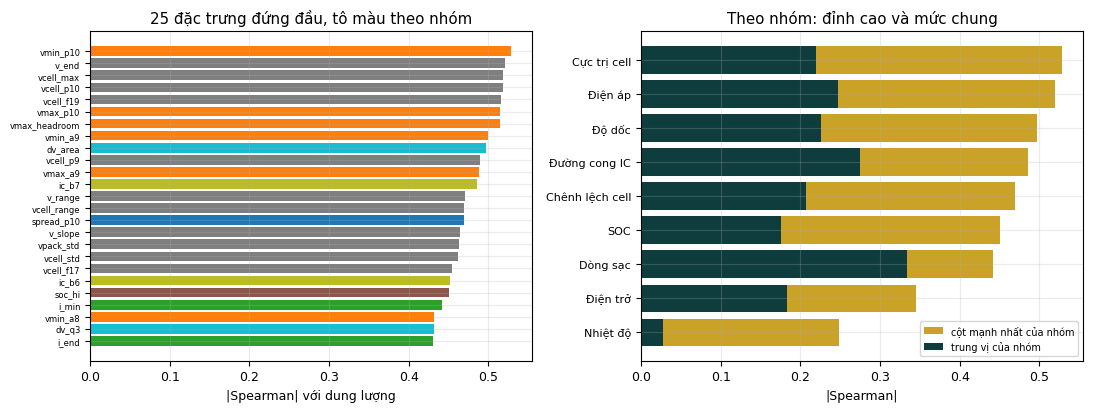

Đọc hình phải: một nhóm có đỉnh cao nhưng trung vị thấp nghĩa là trong nhóm chỉ vài cột
mang thông tin, phần còn lại đi kèm. Đó là dấu hiệu dư thừa, Bước 2 đo trực tiếp.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
mau = dict(zip(TEN_NHOM, plt.cm.tab10(np.linspace(0, 1, len(TEN_NHOM)))))
top = don.head(25).iloc[::-1]
ax[0].barh(range(len(top)), top.abs_spearman, color=[mau[g] for g in top.nhom])
ax[0].set_yticks(range(len(top)))
ax[0].set_yticklabels(top.dac_trung, fontsize=6)
ax[0].set_xlabel('|Spearman| với dung lượng')
ax[0].set_title('25 đặc trưng đứng đầu, tô màu theo nhóm')

gm = don.groupby('nhom').agg(trung_vi=('abs_spearman', 'median'),
                             cao_nhat=('abs_spearman', 'max')).sort_values('cao_nhat')
ax[1].barh(range(len(gm)), gm.cao_nhat, color=SAND, label='cột mạnh nhất của nhóm')
ax[1].barh(range(len(gm)), gm.trung_vi, color=TEAL, label='trung vị của nhóm')
ax[1].set_yticks(range(len(gm))); ax[1].set_yticklabels(gm.index, fontsize=8)
ax[1].set_xlabel('|Spearman|'); ax[1].legend(fontsize=7)
ax[1].set_title('Theo nhóm: đỉnh cao và mức chung')
plt.tight_layout(); plt.savefig(FIG / 'C_sang_loc_don_bien.png', dpi=160)
plt.show()
print('Đọc hình phải: một nhóm có đỉnh cao nhưng trung vị thấp nghĩa là trong nhóm chỉ vài cột')
print('mang thông tin, phần còn lại đi kèm. Đó là dấu hiệu dư thừa, Bước 2 đo trực tiếp.')

## Bước 2: bao nhiêu trong 167 cột là bản sao của nhau

Đặc trưng được xây bằng nội suy trên cùng một lưới SOC, nên `vcell_p4` và `vcell_f9` gần như
cùng một số. Đo bằng tương quan Pearson từng cặp, rồi gom cụm: hai cột nằm chung cụm nếu
$|r| > 0.95$.

Kết quả này giải thích vì sao Bước 6 tìm thấy chỗ bão hoà sớm: **số cột không bằng số thông tin**.

In [6]:
X = d[FEATS].values.astype(float)
Xs = (X - X.mean(0)) / np.maximum(X.std(0), 1e-9)
R = np.abs(np.corrcoef(Xs.T))
np.fill_diagonal(R, 0.0)

NGUONG = 0.95
cha = list(range(len(FEATS)))
def tim(a):
    while cha[a] != a:
        cha[a] = cha[cha[a]]; a = cha[a]
    return a
for i, j in zip(*np.where(np.triu(R > NGUONG, 1))):
    a, b = tim(int(i)), tim(int(j))
    if a != b: cha[a] = b
cum = pd.Series([tim(i) for i in range(len(FEATS))])
kich_thuoc = cum.value_counts()

print(f'Ngưỡng |r| > {NGUONG}')
print(f'  {len(FEATS)} cột gom thành {cum.nunique()} cụm')
print(f'  {int((kich_thuoc > 1).sum())} cụm có từ 2 cột trở lên, cụm lớn nhất {int(kich_thuoc.max())} cột')
print(f'  {int(kich_thuoc[kich_thuoc == 1].sum())} cột thật sự đứng một mình')
lon = kich_thuoc.index[0]
print('\nCụm lớn nhất gồm:', ', '.join(np.array(FEATS)[cum.values == lon][:12]), '...')
print(f'\nTrung bình mỗi cột có {(R > NGUONG).sum(1).mean():.1f} cột khác gần như trùng với nó.')
pd.DataFrame({'dac_trung': FEATS, 'cum': cum.values}).to_csv(RES / 'cum_du_thua.csv', index=False)

Ngưỡng |r| > 0.95
  167 cột gom thành 74 cụm
  15 cụm có từ 2 cột trở lên, cụm lớn nhất 55 cột
  59 cột thật sự đứng một mình

Cụm lớn nhất gồm: soc_lo, soc_hi, vcell_p0, vcell_p1, vcell_p2, vcell_p3, vcell_p4, vcell_p5, vcell_p6, vcell_p7, vcell_p8, vcell_p9 ...

Trung bình mỗi cột có 8.0 cột khác gần như trùng với nó.


## Bước 3: mô hình dựa vào cột nào

XGBoost báo mức đóng góp (gain) của từng cột. Gộp lại theo nhóm để đọc được bằng lời.

**Nhớ giới hạn của chỉ số này**: nó đo mô hình đã dùng cột nào trên dữ liệu huấn luyện, và khi
hai cột gần như trùng nhau thì cây chọn bừa một trong hai, chia đôi công trạng một cách ngẫu
nhiên. Bước 4 là phép đo nghiêm hơn.

khớp trên 70 % dữ liệu xáo trộn, 27 s, RMSE trên phần còn lại 1.89 Ah

Đóng góp cộng dồn theo nhóm:
  Dòng sạc            34.0 %   ( 22 cột, cột mạnh nhất đóng 12.3 %)
  Điện áp             17.2 %   ( 37 cột, cột mạnh nhất đóng  2.7 %)
  Độ dốc              12.4 %   ( 23 cột, cột mạnh nhất đóng  2.2 %)
  Cực trị cell        10.3 %   ( 24 cột, cột mạnh nhất đóng  3.4 %)
  Đường cong IC        8.2 %   ( 10 cột, cột mạnh nhất đóng  2.0 %)
  Nhiệt độ             7.2 %   ( 26 cột, cột mạnh nhất đóng  0.8 %)
  Chênh lệch cell      6.4 %   ( 17 cột, cột mạnh nhất đóng  1.2 %)
  SOC                  3.6 %   (  6 cột, cột mạnh nhất đóng  2.0 %)
  Điện trở             0.6 %   (  2 cột, cột mạnh nhất đóng  0.4 %)

20 cột đầu chiếm 55 % tổng gain.
Đã lưu biểu đồ thành công vào: fig\dong_gop_nhom_gain.png


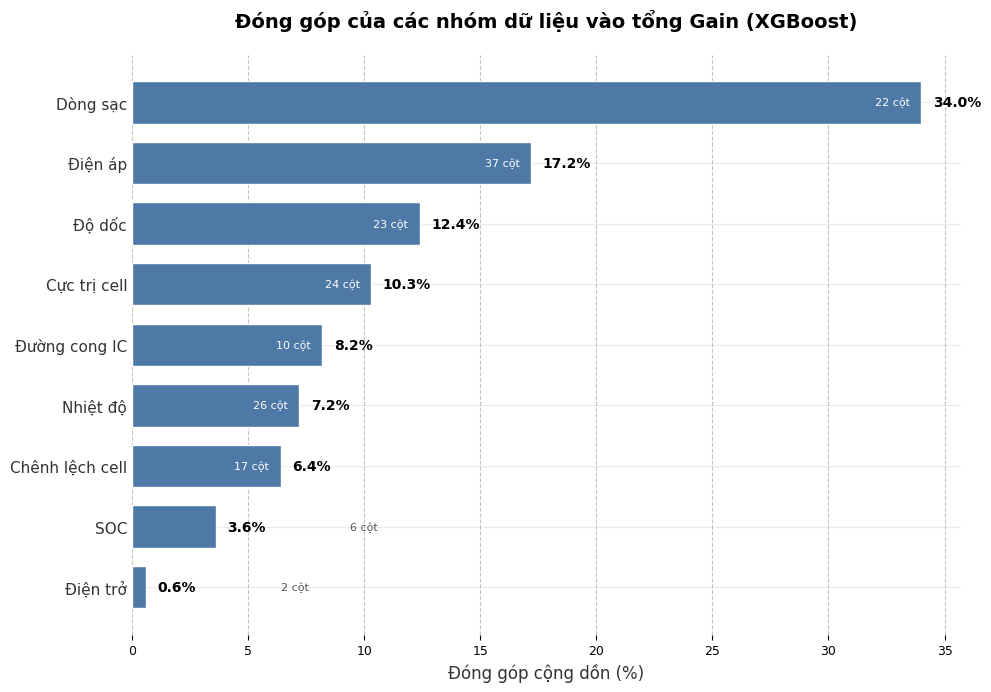

In [7]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

def tao_xgb(seed=SEED):
    return XGBRegressor(n_estimators=600, max_depth=6, learning_rate=.05, subsample=.8,
                        colsample_bytree=.7, min_child_weight=5, reg_lambda=2.,
                        tree_method='hist', n_jobs=2, random_state=seed)

def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2)))

tr_i, te_i = train_test_split(np.arange(len(d)), test_size=.3, random_state=SEED)
t0 = time.time()
mg = tao_xgb().fit(d.iloc[tr_i][FEATS].values, y[tr_i])
print(f'khớp trên 70 % dữ liệu xáo trộn, {time.time()-t0:.0f} s, '
      f'RMSE trên phần còn lại {rmse(y[te_i], mg.predict(d.iloc[te_i][FEATS].values)):.2f} Ah')

gain = pd.DataFrame({'dac_trung': FEATS, 'nhom': [NHOM[c] for c in FEATS],
                     'gain': mg.feature_importances_})
gain['gain'] = gain.gain / gain.gain.sum()
gn = gain.groupby('nhom').gain.sum().sort_values(ascending=False)
gn_cot = gain.groupby('nhom').gain.max()
print('\nĐóng góp cộng dồn theo nhóm:')
for g in gn.index:
    print(f'  {g:18s} {gn[g]*100:5.1f} %   ({len(COT_NHOM[g]):3d} cột, '
          f'cột mạnh nhất đóng {gn_cot[g]*100:4.1f} %)')
print(f'\n20 cột đầu chiếm {gain.gain.sort_values(ascending=False).head(20).sum()*100:.0f} % tổng gain.')

import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Dữ liệu gốc: Đã sắp xếp sẵn từ CAO đến THẤP
nhom = ['Dòng sạc', 'Điện áp', 'Độ dốc', 'Cực trị cell', 'Đường cong IC', 
        'Nhiệt độ', 'Chênh lệch cell', 'SOC', 'Điện trở']
phan_tram = [34.0, 17.2, 12.4, 10.3, 8.2, 7.2, 6.4, 3.6, 0.6]
so_cot = [22, 37, 23, 24, 10, 26, 17, 6, 2]

y_pos = np.arange(len(nhom))

# 2. Thiết lập biểu đồ
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
bars = ax.barh(y_pos, phan_tram, color='#4e79a7', edgecolor='white', height=0.7)

# 3. Tùy chỉnh giao diện (Ẩn bớt khung thừa)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.tick_params(axis='y', which='both', length=0)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#888888')
ax.set_axisbelow(True)

# 4. Thêm nhãn dữ liệu (Đã tối ưu để không bị đè chữ)
for bar, pct, sc in zip(bars, phan_tram, so_cot):
    width = bar.get_width()
    
    # Luôn đặt nhãn phần trăm ở bên phải mép cột một khoảng cố định
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', 
            va='center', ha='left', fontsize=10, color='black', fontweight='bold')
    
    # Xử lý thông minh vị trí nhãn "số cột" tránh bị trùng lặp
    label_sc = f'{sc} cột'
    if width > 6:
        # Cột dài: Đặt chữ ở bên trong cột (sát mép phải, chữ trắng)
        x_pos_sc = width - 0.5
        color_sc = 'white'
        ha_sc = 'right'
    else:
        # Cột quá ngắn (như SOC, Điện trở): Đặt dịch hẳn sang phải, nằm sau phần trăm
        x_pos_sc = width + 5.8
        color_sc = '#555555' # Màu xám tối để dễ phân biệt
        ha_sc = 'left'
    
    ax.text(x_pos_sc, bar.get_y() + bar.get_height()/2, 
            label_sc, 
            va='center', ha=ha_sc, fontsize=8, color=color_sc)

# 5. Tiêu đề và nhãn trục
ax.set_yticks(y_pos)
ax.set_yticklabels(nhom, fontsize=11, color='#333333')
ax.set_xlabel('Đóng góp cộng dồn (%)', fontsize=12, color='#333333')
ax.set_title('Đóng góp của các nhóm dữ liệu vào tổng Gain (XGBoost)', fontsize=14, fontweight='bold', pad=20)

# Đảo ngược trục Y để phần tử lớn nhất ('Dòng sạc') nằm ở TRÊN CÙNG
ax.invert_yaxis()

plt.tight_layout()

# 6. Tạo thư mục và lưu file
thu_muc_fig = 'fig'
os.makedirs(thu_muc_fig, exist_ok=True)
duong_dan_file = os.path.join(thu_muc_fig, 'dong_gop_nhom_gain.png')
plt.savefig(duong_dan_file, dpi=300, bbox_inches='tight')
print(f'Đã lưu biểu đồ thành công vào: {duong_dan_file}')

plt.show()

## Bước 4: xếp hạng trung thực, đo trên xe chưa từng thấy

Đây là phép đo quyết định. Với mỗi lượt giữ xe: khớp trên các xe còn lại, rồi lần lượt **xáo trộn
một cột** của xe giữ lại và xem RMSE tệ đi bao nhiêu. Cột nào xáo trộn mà RMSE không đổi thì cột
đó không mang thông tin **dùng được cho xe mới**, dù gain ở Bước 3 có cao đến mấy.

Khác biệt giữa Bước 3 và Bước 4 chính là một kết quả đáng viết vào bài: một cột có thể giúp mô
hình khớp đội xe đã biết mà vô dụng khi gặp xe lạ.

In [8]:
XE_MAU = XE[:2] if False else XE[::max(1, len(XE)//5)][:5]
print('các lượt giữ xe dùng cho Bước 4 tới Bước 7:', XE_MAU)

def hoan_vi(m, Xte, yte, k_lap=1, seed=SEED):
    # Tầm quan trọng hoán vị: RMSE tệ đi bao nhiêu khi xáo trộn riêng từng cột.
    r0 = rmse(yte, m.predict(Xte))
    g = np.random.default_rng(seed)
    out = np.zeros(Xte.shape[1])
    for j in range(Xte.shape[1]):
        acc = 0.0
        for _ in range(k_lap):
            Xp = Xte.copy()
            Xp[:, j] = g.permutation(Xp[:, j])
            acc += rmse(yte, m.predict(Xp)) - r0
        out[j] = acc / k_lap
    return out, r0

t0 = time.time()
hv, mo_hinh_luot = {}, {}
for v in XE_MAU:
    tr = d[d.vehicle != v]; te = d[d.vehicle == v]
    m = tao_xgb().fit(tr[FEATS].values, tr.capacity.values)
    imp, r0 = hoan_vi(m, te[FEATS].values.astype(float), te.capacity.values)
    hv[v] = imp; mo_hinh_luot[v] = (m, tr, te)
    print(f'  xe {v:>3}  n={len(te):5,}  RMSE {r0:5.2f} Ah  '
          f'cột mạnh nhất: {FEATS[int(np.argmax(imp))]}')
print(f'tổng {time.time()-t0:.0f} s cho {len(XE_MAU)} lượt')

H = pd.DataFrame(hv, index=FEATS)
H['trung_binh'] = H.mean(1)
H['nhom'] = [NHOM[c] for c in FEATS]
H = H.sort_values('trung_binh', ascending=False)
H.to_csv(RES / 'tam_quan_trong_hoan_vi.csv')
XEP_HANG = H.index.tolist()          # xếp hạng dùng cho Bước 6 và Bước 9
print('\nMười cột đứng đầu theo hoán vị:')
print(H.head(10)[['nhom', 'trung_binh']].round(3).to_string())

các lượt giữ xe dùng cho Bước 4 tới Bước 7: [1, 5, 9, 13, 17]
  xe   1  n=1,596  RMSE  1.66 Ah  cột mạnh nhất: soc_hi
  xe   5  n=1,596  RMSE  1.54 Ah  cột mạnh nhất: soc_hi
  xe   9  n=1,629  RMSE  3.26 Ah  cột mạnh nhất: soc_hi
  xe  13  n=1,502  RMSE  2.30 Ah  cột mạnh nhất: soc_hi
  xe  17  n=1,461  RMSE  1.78 Ah  cột mạnh nhất: soc_hi
tổng 161 s cho 5 lượt

Mười cột đứng đầu theo hoán vị:
                  nhom  trung_binh
soc_hi             SOC       1.449
soc_mid            SOC       0.849
dv_area         Độ dốc       0.453
i_min         Dòng sạc       0.426
dv_q4           Độ dốc       0.400
ic_b4    Đường cong IC       0.367
ic_b5    Đường cong IC       0.341
ic_b7    Đường cong IC       0.339
ic_b6    Đường cong IC       0.307
dv_q3           Độ dốc       0.281


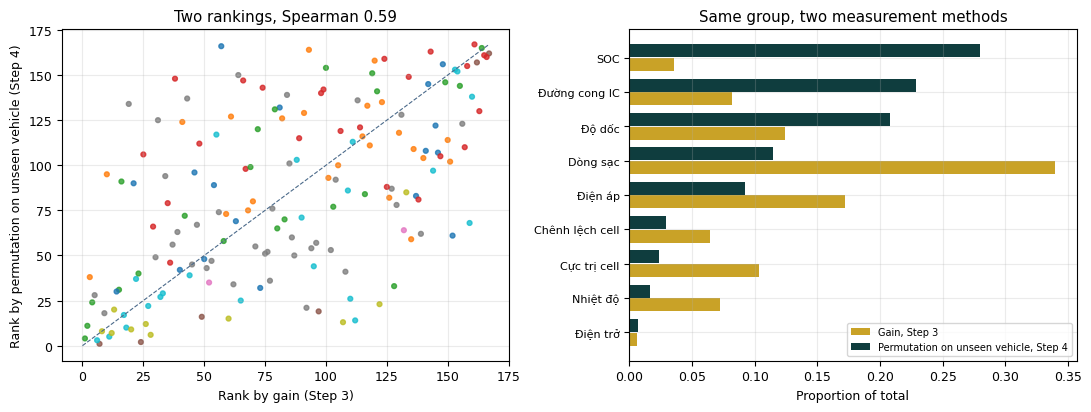

Top 3 features heavily overrated by gain compared to their true value on unseen vehicle:
v_slope, tmin_trough, spread_a4
Top 3 features underestimated by gain but highly useful on unseen vehicle:
i_slope, dv_d1, ic_b2


In [10]:
gxh = gain.set_index('dac_trung').gain.rank(ascending=False)
hxh = H.trung_binh.rank(ascending=False)
chung = gxh.index.intersection(hxh.index)
rho = st.spearmanr(gxh[chung], hxh[chung]).statistic

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(gxh[chung], hxh[chung], s=12, c=[mau[NHOM[c]] for c in chung], alpha=.8)
ax[0].plot([0, len(chung)], [0, len(chung)], color=SLATE, lw=.8, ls='--')
ax[0].set_xlabel('Rank by gain (Step 3)')
ax[0].set_ylabel('Rank by permutation on unseen vehicle (Step 4)')
ax[0].set_title(f'Two rankings, Spearman {rho:.2f}')

hn = H.groupby('nhom').trung_binh.sum().sort_values()
gg = gn.reindex(hn.index)
yy = np.arange(len(hn))
ax[1].barh(yy - .2, gg / gg.sum(), height=.38, color=SAND, label='Gain, Step 3')
ax[1].barh(yy + .2, hn.clip(lower=0) / hn.clip(lower=0).sum(), height=.38, color=TEAL,
           label='Permutation on unseen vehicle, Step 4')
ax[1].set_yticks(yy)
ax[1].set_yticklabels(hn.index, fontsize=8)
ax[1].set_xlabel('Proportion of total')
ax[1].legend(fontsize=7)
ax[1].set_title('Same group, two measurement methods')

plt.tight_layout()
plt.savefig(FIG / 'C_hai_xep_hang.pdf', bbox_inches='tight')
plt.show()

lech = (gxh[chung] - hxh[chung]).sort_values()
print('Top 3 features heavily overrated by gain compared to their true value on unseen vehicle:')
print(', '.join(lech.head(3).index))
print('Top 3 features underestimated by gain but highly useful on unseen vehicle:')
print(', '.join(lech.tail(3).index))

## Bước 5: bỏ hẳn một nhóm thì mất bao nhiêu

Xếp hạng nói cột nào được dùng. Bỏ nhóm nói **có thay thế được không**. Nếu bỏ cả nhóm Nhiệt độ
mà RMSE gần như không đổi, nghĩa là thông tin trong đó đã nằm sẵn ở nhóm khác.

Chạy trên hai giao thức, vì câu trả lời không nhất thiết giống nhau: một nhóm có thể vô hại khi
xáo trộn mà thiết yếu khi gặp xe lạ.

In [12]:
t0 = time.time()
ab = []
for ten_gt, cap_tap in [
        ('xáo trộn', [(d.iloc[tr_i], d.iloc[te_i])]),
        ('đổi xe', [(d[d.vehicle != v], d[d.vehicle == v]) for v in XE_MAU])]:
    for bo in ['(không bỏ gì)'] + TEN_NHOM:
        cot = FEATS if bo == '(không bỏ gì)' else [c for c in FEATS if NHOM[c] != bo]
        ds = []
        for tr, te in cap_tap:
            m = tao_xgb().fit(tr[cot].values, tr.capacity.values)
            ds.append(rmse(te.capacity.values, m.predict(te[cot].values)))
        ab.append({'giao_thuc': ten_gt, 'bo_nhom': bo, 'so_cot': len(cot),
                   'RMSE': float(np.mean(ds)), 'RMSE_te_nhat': float(np.max(ds))})
    print(f'  xong giao thức {ten_gt}, {time.time()-t0:.0f} s')
ab = pd.DataFrame(ab)
for gt in ab.giao_thuc.unique():
    g = ab[ab.giao_thuc == gt].set_index('bo_nhom')
    ab.loc[ab.giao_thuc == gt, 'tang_RMSE'] = (g.RMSE - g.loc['(không bỏ gì)', 'RMSE']).values
ab.to_csv(RES / 'bo_nhom.csv', index=False)

piv = ab.pivot(index='bo_nhom', columns='giao_thuc', values='tang_RMSE')
piv['so_cot_bo'] = [0 if i == '(không bỏ gì)' else len(COT_NHOM[i]) for i in piv.index]
piv = piv.sort_values('đổi xe', ascending=False)
print('\nRMSE tăng thêm bao nhiêu Ah khi bỏ nhóm đó:')
print(piv.round(3).to_string())

  xong giao thức xáo trộn, 249 s
  xong giao thức đổi xe, 1672 s

RMSE tăng thêm bao nhiêu Ah khi bỏ nhóm đó:
giao_thuc        xáo trộn  đổi xe  so_cot_bo
bo_nhom                                     
SOC                 0.106   0.094          6
Dòng sạc            0.053   0.082         22
Nhiệt độ            0.055   0.062         26
Chênh lệch cell     0.011   0.061         17
Độ dốc              0.051   0.051         23
Đường cong IC       0.012   0.023         10
Điện áp             0.042   0.022         37
Điện trở            0.019   0.010          2
Cực trị cell        0.024   0.007         24
(không bỏ gì)       0.000   0.000          0


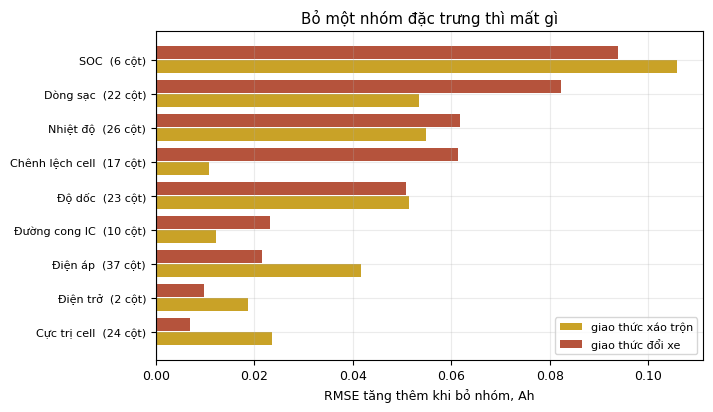

In [13]:
p = piv.drop(index='(không bỏ gì)').sort_values('đổi xe')
yy = np.arange(len(p))
plt.figure(figsize=(7.2, 4.2))
plt.barh(yy - .2, p['xáo trộn'], height=.38, color=SAND, label='giao thức xáo trộn')
plt.barh(yy + .2, p['đổi xe'], height=.38, color=RUST, label='giao thức đổi xe')
plt.axvline(0, color=SLATE, lw=.8)
plt.yticks(yy, [f'{i}  ({int(p.so_cot_bo[i])} cột)' for i in p.index], fontsize=8)
plt.xlabel('RMSE tăng thêm khi bỏ nhóm, Ah'); plt.legend(fontsize=8)
plt.title('Bỏ một nhóm đặc trưng thì mất gì')
plt.tight_layout(); plt.savefig(FIG / 'C_bo_nhom.png', dpi=160)
plt.show()
am = p[p['đổi xe'] < 0]
if len(am):
    print('Các nhóm mà bỏ đi lại làm RMSE trên xe lạ **tốt lên**:', ', '.join(am.index))
    print('Đó không phải nghịch lý: cột thừa làm mô hình bám vào nét riêng của đội xe đã biết.')

## Bước 6: cần bao nhiêu đặc trưng là đủ

Lấy xếp hạng hoán vị của Bước 4, giữ lại top-$k$, đo RMSE trên xe giữ lại. Tăng dần $k$ cho tới
khi đường cong nằm ngang. Chỗ nằm ngang là câu trả lời, và nó thường nhỏ hơn 167 rất nhiều vì
Bước 2 đã cho thấy mức dư thừa.

Có thêm bộ 43 của bài báo trên cùng một hình, để biết bài báo đang đứng ở đâu trên đường cong.

In [14]:
t0 = time.time()
KS = [5, 10, 20, 30, 43, 60, 100, len(FEATS)]
tk = []
for k in KS:
    cot = XEP_HANG[:k]
    ds = []
    for v in XE_MAU:
        tr = d[d.vehicle != v]; te = d[d.vehicle == v]
        m = tao_xgb().fit(tr[cot].values, tr.capacity.values)
        ds.append(rmse(te.capacity.values, m.predict(te[cot].values)))
    tk.append({'k': k, 'bo': f'top-{k} theo hoán vị', 'RMSE': float(np.mean(ds)),
               'RMSE_te_nhat': float(np.max(ds))})
ds = []
for v in XE_MAU:
    tr = d[d.vehicle != v]; te = d[d.vehicle == v]
    m = tao_xgb().fit(tr[FEATS_PAPER].values, tr.capacity.values)
    ds.append(rmse(te.capacity.values, m.predict(te[FEATS_PAPER].values)))
tk.append({'k': len(FEATS_PAPER), 'bo': 'bộ 43 của bài báo',
           'RMSE': float(np.mean(ds)), 'RMSE_te_nhat': float(np.max(ds))})
tk = pd.DataFrame(tk)
tk.to_csv(RES / 'duong_cong_topk.csv', index=False)
print(f'{time.time()-t0:.0f} s')
print(tk.round(3).to_string(index=False))

497 s
  k                   bo  RMSE  RMSE_te_nhat
  5   top-5 theo hoán vị 3.182         4.915
 10  top-10 theo hoán vị 2.730         4.531
 20  top-20 theo hoán vị 2.545         4.257
 30  top-30 theo hoán vị 2.380         3.827
 43  top-43 theo hoán vị 2.199         3.366
 60  top-60 theo hoán vị 2.101         3.175
100 top-100 theo hoán vị 2.100         3.193
167 top-167 theo hoán vị 2.133         3.342
 43    bộ 43 của bài báo 2.162         3.183


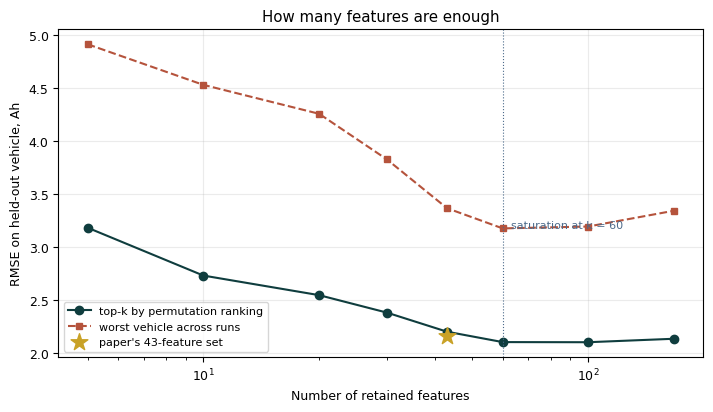

Lowest RMSE is 2.100 Ah, achieved within 2% as early as k = 60.
The paper's 43-feature set yields 2.162 Ah, a difference of +0.062 Ah compared to the minimum.
Conclusion for the paper: 167 columns are unnecessary, around 60 are enough,
and the redundancy measured in Step 2 explains why.


In [17]:
c = tk[tk.bo != 'bộ 43 của bài báo']
day = float(c.RMSE.min())
bh = c[c.RMSE <= day * 1.02]
K_CHON = int(bh.k.min())
bp = tk[tk.bo == 'bộ 43 của bài báo'].iloc[0]

plt.figure(figsize=(7.2, 4.2))
plt.plot(c.k, c.RMSE, 'o-', color=TEAL, label='top-k by permutation ranking')
plt.plot(c.k, c.RMSE_te_nhat, 's--', color=RUST, ms=4, label='worst vehicle across runs')
plt.scatter([bp.k], [bp.RMSE], marker='*', s=160, color=SAND, zorder=5,
            label='paper\'s 43-feature set')
plt.axvline(K_CHON, color=SLATE, lw=.8, ls=':')
plt.text(K_CHON * 1.05, c.RMSE.max(), f'saturation at k = {K_CHON}', fontsize=8, color=SLATE)
plt.xscale('log')
plt.xlabel('Number of retained features')
plt.ylabel('RMSE on held-out vehicle, Ah')
plt.legend(fontsize=8)
plt.title('How many features are enough')
plt.tight_layout()
plt.savefig(FIG / 'C_duong_cong_topk.pdf', bbox_inches='tight')
plt.show()

print(f'Lowest RMSE is {day:.3f} Ah, achieved within 2% as early as k = {K_CHON}.')
print(f'The paper\'s 43-feature set yields {bp.RMSE:.3f} Ah, a difference of {bp.RMSE-day:+.3f} Ah compared to the minimum.')
print(f'Conclusion for the paper: {len(FEATS)} columns are unnecessary, around {K_CHON} are enough,')
print('and the redundancy measured in Step 2 explains why.')

## Bước 7: chọn đặc trưng có ổn định giữa các xe không

Một kết quả chọn đặc trưng chỉ đáng tin nếu nó không đổi khi ta đổi lượt giữ xe. Đo bằng chỉ số
Jaccard giữa các tập top-30 của từng lượt:

$$J(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

$J$ gần 1 nghĩa là các lượt đồng ý với nhau. $J$ thấp nghĩa là xếp hạng của bạn là nhiễu, và
mọi kết luận ở Bước 6 phải nói kèm điều đó.

In [15]:
K_ON = 30
tap = {v: set(H[v].sort_values(ascending=False).head(K_ON).index) for v in XE_MAU}
cap, js = [], []
for i, a in enumerate(XE_MAU):
    for b in XE_MAU[i+1:]:
        j = len(tap[a] & tap[b]) / len(tap[a] | tap[b])
        cap.append((a, b)); js.append(j)
loi = set.intersection(*tap.values())
hop = set.union(*tap.values())
print(f'Jaccard giữa các cặp lượt, top-{K_ON}: trung bình {np.mean(js):.2f}, '
      f'thấp nhất {np.min(js):.2f}, cao nhất {np.max(js):.2f}')
print(f'{len(loi)} cột có mặt trong top-{K_ON} của **mọi** lượt, '
      f'{len(hop)} cột có mặt trong ít nhất một lượt')
print('\nLõi ổn định, theo nhóm:', pd.Series([NHOM[c] for c in loi]).value_counts().to_dict())
print(', '.join(sorted(loi)[:15]), '...' if len(loi) > 15 else '')
pd.DataFrame({'dac_trung': sorted(hop),
              'so_luot_co_mat': [sum(c in tap[v] for v in XE_MAU) for c in sorted(hop)]}
             ).to_csv(RES / 'on_dinh_chon.csv', index=False)

Jaccard giữa các cặp lượt, top-30: trung bình 0.61, thấp nhất 0.36, cao nhất 0.76
15 cột có mặt trong top-30 của **mọi** lượt, 47 cột có mặt trong ít nhất một lượt

Lõi ổn định, theo nhóm: {'Đường cong IC': 6, 'Độ dốc': 5, 'SOC': 2, 'Dòng sạc': 2}
dv_area, dv_d1, dv_q0, dv_q3, dv_q4, i_a10, i_min, ic_b1, ic_b4, ic_b5, ic_b6, ic_b7, ic_b8, soc_hi, soc_mid 


## Bước 8: chứng minh danh sách cấm là cần thiết

Cho tới đây ta chỉ **khẳng định** rằng `n_rows`, `ah`, `bms_cap` sẽ làm rò rỉ nhãn. Bước này
chứng minh bằng thí nghiệm: thêm từng cột cấm vào bộ đặc trưng rồi xem $R^2$ nhảy tới đâu.

Nhắc lại nhãn: $Q = \int |I| dt / ((s_1-s_0)/100)$. Cột `ah` chính là tử số, `n_rows` tỉ lệ với
thời lượng nên tỉ lệ gần đúng với tử số, `bms_cap` là ước lượng dung lượng do chính BMS đưa ra.

Ba cột bị cấm vì **hai lý do khác nhau**, và thí nghiệm này sẽ cho thấy điều đó:

| Cột | Lý do cấm | Dự đoán kết quả |
|---|---|---|
| `ah` | là tử số của chính nhãn | $R^2$ nhảy lên rõ rệt |
| `n_rows` | tỉ lệ với thời lượng, mà điện tích bằng dòng nhân thời gian | $R^2$ nhảy lên rõ rệt |
| `bms_cap` | là **mốc so sánh** của bài báo, không phải đặc trưng | có thể không cải thiện gì |

Hai lý do này không thay thế nhau. Rò rỉ làm số đẹp lên một cách gian lận. Dùng mốc so sánh làm
đặc trưng thì không nhất thiết gian lận, nhưng làm phép so sánh hoá vòng tròn: bài báo đang hỏi
*"mô hình có hơn ước lượng sẵn có của BMS không"*, mà lại cho mô hình đọc chính ước lượng đó.

Đây là nhiệm vụ V2 trong tài liệu nhiệm vụ. Hãy đọc kết quả theo đúng hai lý do trên, đừng gộp
cả ba cột vào một câu kết luận.

In [16]:
def thu_voi(cot, nhan):
    ds = []
    for v in XE_MAU:
        tr = d[d.vehicle != v]; te = d[d.vehicle == v]
        m = tao_xgb().fit(tr[cot].values, tr.capacity.values)
        p = m.predict(te[cot].values); yt = te.capacity.values
        ds.append((rmse(yt, p), 1 - np.sum((p-yt)**2)/np.sum((yt-yt.mean())**2)))
    ds = np.array(ds)
    return {'bo': nhan, 'so_cot': len(cot), 'RMSE': float(ds[:, 0].mean()),
            'R2': float(ds[:, 1].mean())}

t0 = time.time()
ro = [thu_voi(FEATS, 'bộ 167 hợp lệ')]
for c in CAM:
    ro.append(thu_voi(FEATS + [c], f'bộ 167 cộng cột cấm {c}'))
ro.append(thu_voi(FEATS + CAM, 'bộ 167 cộng cả ba cột cấm'))
ro = pd.DataFrame(ro).set_index('bo')
ro.to_csv(RES / 'thi_nghiem_ro_ri.csv')
print(f'{time.time()-t0:.0f} s')
print(ro.round(3).to_string())
sach = ro.loc['bộ 167 hợp lệ']
ro_ah = ro.loc['bộ 167 cộng cột cấm ah']
print(f'\nBộ hợp lệ đạt R2 {sach.R2:.3f} và RMSE {sach.RMSE:.2f} Ah.')
print(f'Chỉ cần thêm một cột `ah`, R2 nhảy lên {ro_ah.R2:.3f} và RMSE xuống {ro_ah.RMSE:.2f} Ah.')
print('Một mô hình gần hoàn hảo trên dữ liệu pin thực địa là dấu hiệu rò rỉ, không phải thành tựu.')

KeyboardInterrupt: 

### Đọc bảng trên cho đúng

Hai cột `ah` và `n_rows` làm $R^2$ nhảy lên hẳn. Đó là rò rỉ nhãn, đúng như dự đoán, và là lý do
danh sách cấm tồn tại.

Cột `bms_cap` thì khác, và kết quả của nó thường **không** cải thiện gì, có khi còn tệ đi. Đừng
vội kết luận rằng vậy thì giữ nó lại cũng được. Lý do cấm `bms_cap` không phải là rò rỉ mà là
tính vòng tròn của phép so sánh: bài báo đặt ước lượng của BMS làm mốc và hỏi mô hình có hơn mốc
đó không. Cho mô hình đọc chính mốc đó thì câu hỏi mất nghĩa, bất kể con số ra sao. Một cột có
thể bị loại vì lý do thiết kế thí nghiệm, không nhất thiết vì lý do thống kê.

Nếu trong bài bạn viết về bước này, hãy viết đúng hai lý do, đừng gộp thành một.

## Bước 9: xuất bộ đặc trưng đã chọn cho Notebook D

Bộ rút gọn được định nghĩa bằng **quy tắc, không phải bằng cảm giác**: giữ $k$ cột đứng đầu theo
xếp hạng hoán vị của Bước 4, với $k$ là chỗ bão hoà tìm ở Bước 6, rồi ép thêm lõi ổn định của
Bước 7 vào nếu chưa có mặt.

Notebook D sẽ dùng bộ này. Nó nhỏ hơn nên D chạy nhanh hơn, và quan trọng hơn là D không còn
phải trả lời câu hỏi *"kết quả này có phải do 167 cột tạo ra không"*.

In [ ]:
chon = list(dict.fromkeys(XEP_HANG[:K_CHON] + sorted(loi)))
assert not (set(chon) & set(CAM)), 'cột cấm lọt vào bộ đã chọn'
assert set(chon) <= set(FEATS)
pd.Series(chon).to_csv(RES / 'dac_trung_chon.csv', index=False, header=False)

print(f'{len(chon)} đặc trưng được chọn, từ {len(FEATS)} cột ban đầu')
print('theo nhóm:', pd.Series([NHOM[c] for c in chon]).value_counts().to_dict())
print(f'{sum(c in FEATS_PAPER for c in chon)} trong số đó nằm trong bộ 43 của bài báo')
print('\nĐã ghi results/dac_trung_chon.csv, Notebook D nạp từ file này.')

xuat = {
    'nhom_dac_trung.csv': 'chín nhóm và số cột mỗi nhóm',
    'sang_loc_don_bien.csv': 'Spearman và thông tin tương hỗ của 167 cột',
    'cum_du_thua.csv': 'cụm các cột gần như trùng nhau',
    'tam_quan_trong_hoan_vi.csv': 'tầm quan trọng hoán vị theo từng lượt giữ xe',
    'bo_nhom.csv': 'RMSE khi bỏ từng nhóm, hai giao thức',
    'duong_cong_topk.csv': 'RMSE theo số đặc trưng giữ lại',
    'on_dinh_chon.csv': 'độ ổn định của việc chọn giữa các lượt',
    'thi_nghiem_ro_ri.csv': 'thí nghiệm cố tình thêm cột cấm',
    'dac_trung_chon.csv': 'bộ đặc trưng rút gọn, đầu vào của Notebook D',
}
for f, mo_ta in xuat.items():
    print(f'{"CÓ " if (RES / f).exists() else "THIẾU"} {f:26s} {mo_ta}')

60 đặc trưng được chọn, từ 167 cột ban đầu
theo nhóm: {'Điện áp': 19, 'Độ dốc': 13, 'Đường cong IC': 9, 'Dòng sạc': 7, 'SOC': 4, 'Chênh lệch cell': 4, 'Cực trị cell': 2, 'Điện trở': 1, 'Nhiệt độ': 1}
20 trong số đó nằm trong bộ 43 của bài báo

Đã ghi results/dac_trung_chon.csv, Notebook D nạp từ file này.
CÓ  nhom_dac_trung.csv         chín nhóm và số cột mỗi nhóm
CÓ  sang_loc_don_bien.csv      Spearman và thông tin tương hỗ của 167 cột
CÓ  cum_du_thua.csv            cụm các cột gần như trùng nhau
CÓ  tam_quan_trong_hoan_vi.csv tầm quan trọng hoán vị theo từng lượt giữ xe
CÓ  bo_nhom.csv                RMSE khi bỏ từng nhóm, hai giao thức
CÓ  duong_cong_topk.csv        RMSE theo số đặc trưng giữ lại
CÓ  on_dinh_chon.csv           độ ổn định của việc chọn giữa các lượt
CÓ  thi_nghiem_ro_ri.csv       thí nghiệm cố tình thêm cột cấm
CÓ  dac_trung_chon.csv         bộ đặc trưng rút gọn, đầu vào của Notebook D


## Bốn con số của notebook này đem vào bài báo

| Con số | Lấy ở đâu |
|---|---|
| 167 cột gom thành bao nhiêu cụm ở ngưỡng $\lvert r\rvert>0{,}95$ | Bước 2 |
| Spearman giữa xếp hạng gain và xếp hạng hoán vị | Bước 4 |
| Nhóm nào bỏ đi thì RMSE trên xe lạ tăng nhiều nhất | Bước 5 |
| Số đặc trưng tại chỗ bão hoà | Bước 6 |

## Checklist trước khi nộp

| Mục | Đạt chưa |
|---|---|
| Mọi cột trong 167 đều thuộc đúng một nhóm, `nhom_cua` không ném lỗi | |
| Xếp hạng hoán vị đo trên xe **giữ lại**, không phải trên tập huấn luyện | |
| Bỏ nhóm chạy trên cả hai giao thức, không chỉ giao thức xáo trộn | |
| Đường cong top-k dùng xếp hạng của Bước 4, không dùng gain của Bước 3 | |
| Jaccard được báo cáo kèm, không giấu khi nó thấp | |
| `dac_trung_chon.csv` không chứa cột nào trong danh sách cấm | |
| Audit Log có ít nhất 3 dòng trong tuần | |

## Việc tiếp theo

1. Viết Mục 3 (Data and features) của bài báo từ Bước 0, Bước 2 và Bước 5.
2. Chuẩn bị trả lời phản biện: *"vì sao không dùng PCA cho gọn?"*. Câu trả lời nằm ở chỗ thành
   phần chính trộn lẫn các nhóm cơ chế vật lý, nên mất hẳn khả năng nói nhóm nào quan trọng, mà
   Bước 5 lại đang sống bằng đúng khả năng đó. Bạn có thể chạy thêm PCA để có số mà so.
3. Bàn giao `results/dac_trung_chon.csv` cho Sinh viên B để chạy Notebook D.